<a href="https://colab.research.google.com/github/juanes6554/ML_Course-Homeworks/blob/main/HomeValue_AI_House_Price_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Juan Daniel Díaz Andrade**

Notebook link: https://www.kaggle.com/code/miadul/

Dataset link: homevalue-ai-house-price-predictio/notebook
https://www.kaggle.com/datasets/raviiyadavv/house-price-predecition

# 🏠 House Price Prediction — End-to-End Machine Learning Project

This notebook builds a complete **House Price Prediction** project using a structured housing dataset.

## Project Goals

- Understand the dataset and all features
- Perform exploratory data analysis (EDA)
- Handle missing values
- Engineer useful features
- Train multiple regression models
- Compare model performance
- Save the best model for deployment

## Target Column

`Price` — house price to be predicted.

## 1. Import Required Libraries

In [10]:
import os
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import joblib

pd.set_option("display.max_columns", None)
sns.set_context("notebook")

## 2. Load Dataset

In [11]:

from google.colab import drive
drive.mount('/content/drive')
ruta_drive = '/content/drive/My Drive/Colab Notebooks/dataset_2.csv'
df = pd.read_csv(ruta_drive)
df.head()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


,Area_SqFt,Rooms,Build_Year,Location,Street_Type,Furnishing,Property_Type,Has_Pool,Price
0,2473.192784,4.0,1992,Jaipur,Residential Lane,Furnished,Apartment,No,568486.0
1,2353.472711,4.0,2006,Indore,Corner Plot,Unfurnished,Apartment,Yes,577214.0
2,2212.222005,3.0,2012,Jaipur,Highway Facing,Semi-Furnished,Duplex,No,581300.0
3,2823.886596,6.0,1993,Lucknow,Main Road,Unfurnished,Villa,Yes,794614.0
4,1869.648721,5.0,2012,Jaipur,Corner Plot,Semi-Furnished,Apartment,No,493086.0


## 3. Dataset Overview

In [12]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])
print("Column Names:")
print(df.columns.tolist())

Rows: 1124
Columns: 9
Column Names:
['Area_SqFt', 'Rooms', 'Build_Year', 'Location', 'Street_Type', 'Furnishing', 'Property_Type', 'Has_Pool', 'Price']


In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1124 entries, 0 to 1123
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Area_SqFt      1091 non-null   float64
 1   Rooms          1091 non-null   float64
 2   Build_Year     1124 non-null   int64  
 3   Location       1124 non-null   object 
 4   Street_Type    1124 non-null   object 
 5   Furnishing     1091 non-null   object 
 6   Property_Type  1124 non-null   object 
 7   Has_Pool       1124 non-null   object 
 8   Price          1124 non-null   float64
dtypes: float64(3), int64(1), object(5)
memory usage: 79.2+ KB


In [14]:
df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Area_SqFt,1091.0,NaN,NaN,NaN,2237.479473,731.097828,700.0,1834.022964,2201.545784,2576.139355,10267.12433
Rooms,1091.0,NaN,NaN,NaN,4.568286,1.678155,2.0,3.0,5.0,6.0,7.0
Build_Year,1124.0,NaN,NaN,NaN,2005.080071,11.708876,1985.0,1995.0,2005.0,2015.0,2024.0
Location,1124,8,Noida,156,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Street_Type,1124,5,Highway Facing,242,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Furnishing,1091,3,Semi-Furnished,451,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Property_Type,1124,4,Apartment,536,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Has_Pool,1124,2,No,827,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Price,1124.0,NaN,NaN,NaN,608201.51472,143195.809492,248640.0,516194.75,602541.0,689578.5,2071401.84


## 4. Feature Notes

| Feature | Type | Meaning |
|---|---|---|
| `Area_SqFt` | Numerical | House area in square feet |
| `Rooms` | Numerical | Number of rooms |
| `Build_Year` | Numerical | Year when the house was built |
| `Location` | Categorical | House location |
| `Street_Type` | Categorical | Type of street/road |
| `Furnishing` | Categorical | Furnishing condition |
| `Property_Type` | Categorical | Apartment, Villa, Duplex etc. |
| `Has_Pool` | Categorical | Whether the property has a pool |
| `Price` | Numerical | Target variable |

## 5. Missing Value Analysis

In [15]:
missing = df.isnull().sum().sort_values(ascending=False)
missing_percent = (df.isnull().mean() * 100).sort_values(ascending=False)
missing_df = pd.DataFrame({"Missing_Count": missing, "Missing_Percentage": missing_percent})
missing_df[missing_df["Missing_Count"] > 0]

,Missing_Count,Missing_Percentage
Area_SqFt,33,2.935943
Rooms,33,2.935943
Furnishing,33,2.935943


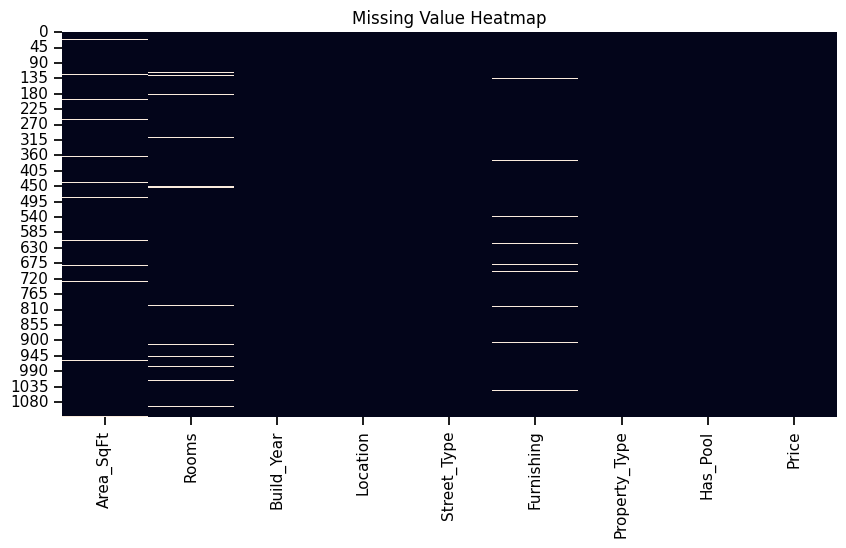

In [16]:
plt.figure(figsize=(10, 5))
sns.heatmap(df.isnull(), cbar=False)
plt.title("Missing Value Heatmap")
plt.show()

## 6. Duplicate Check

In [17]:
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 0


## 7. Target Variable Analysis — Price

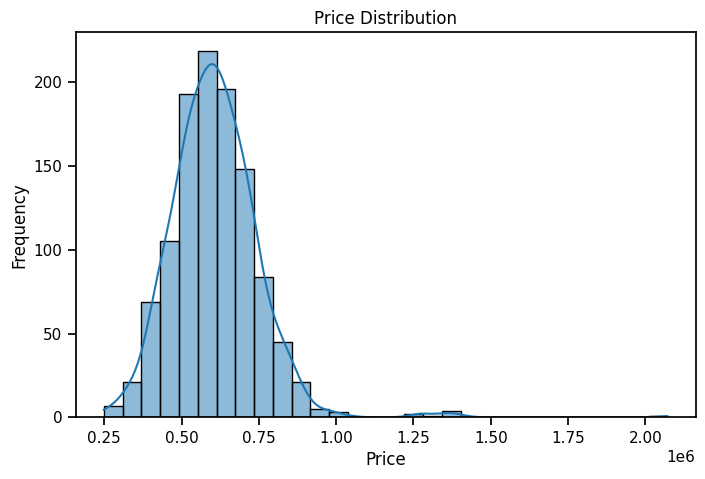

In [18]:
plt.figure(figsize=(8, 5))
sns.histplot(df["Price"], kde=True, bins=30)
plt.title("Price Distribution")
plt.xlabel("Price")
plt.ylabel("Frequency")
plt.show()

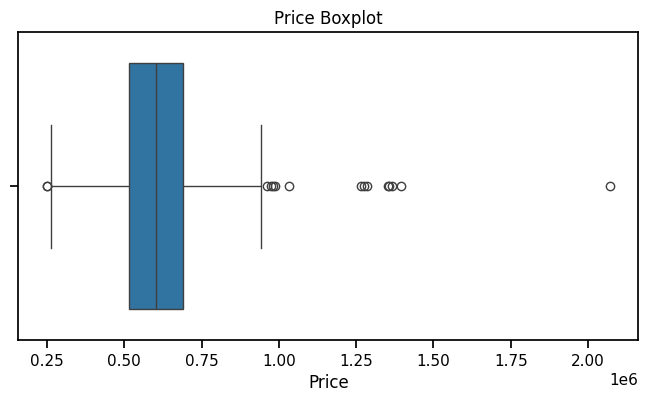

In [19]:
plt.figure(figsize=(8, 4))
sns.boxplot(x=df["Price"])
plt.title("Price Boxplot")
plt.show()

## 8. Numerical Feature Analysis

In [20]:
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
numeric_cols

['Area_SqFt', 'Rooms', 'Build_Year', 'Price']

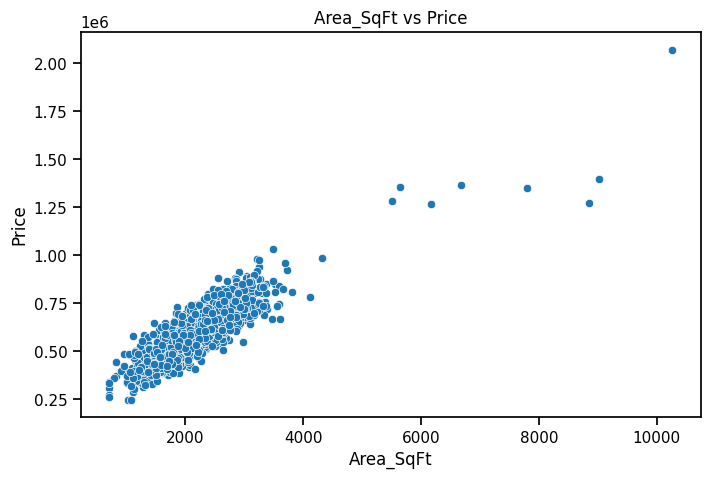

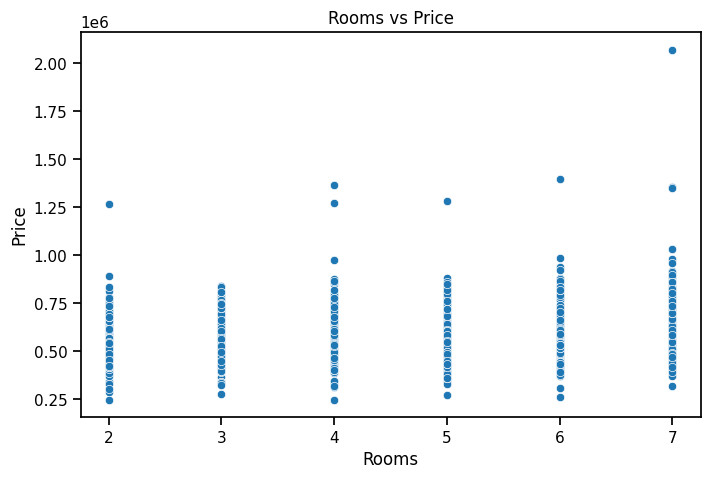

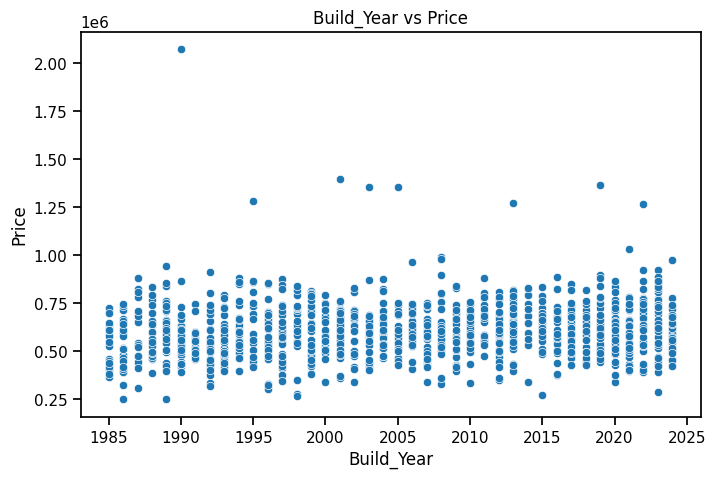

In [21]:
for col in ["Area_SqFt", "Rooms", "Build_Year"]:
    plt.figure(figsize=(8, 5))
    sns.scatterplot(data=df, x=col, y="Price")
    plt.title(f"{col} vs Price")
    plt.show()

## 9. Categorical Feature Analysis

In [22]:
categorical_cols = df.select_dtypes(include="object").columns.tolist()
categorical_cols

['Location', 'Street_Type', 'Furnishing', 'Property_Type', 'Has_Pool']

In [23]:
for col in categorical_cols:
    print(f"{col} value counts:")
    display(df[col].value_counts())

Location value counts:


,count
Location,
Noida,156
Kanpur,147
Prayagraj,146
Delhi,144
Lucknow,138
Indore,133
Jaipur,133
Gurugram,127


Street_Type value counts:


,count
Street_Type,
Highway Facing,242
Residential Lane,229
Main Road,229
Corner Plot,212
Gated Society,212


Furnishing value counts:


,count
Furnishing,
Semi-Furnished,451
Furnished,379
Unfurnished,261


Property_Type value counts:


,count
Property_Type,
Apartment,536
Independent House,324
Duplex,155
Villa,109


Has_Pool value counts:


,count
Has_Pool,
No,827
Yes,297


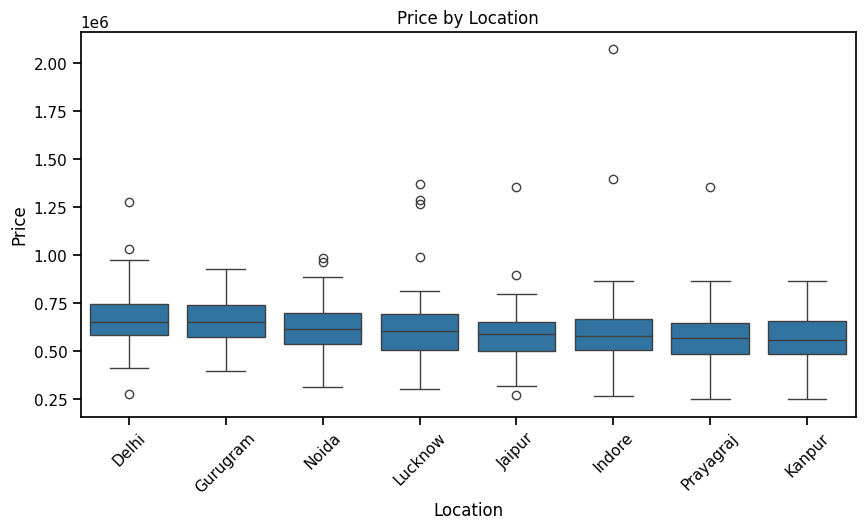

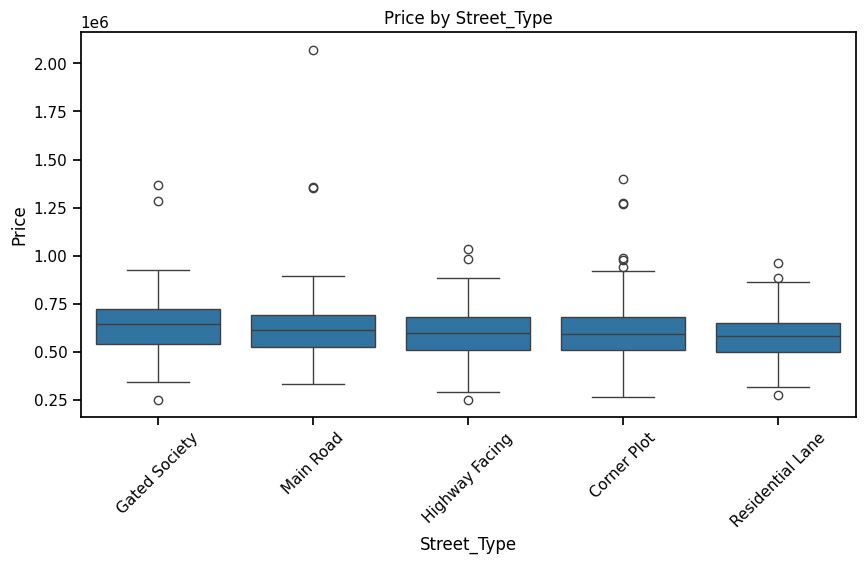

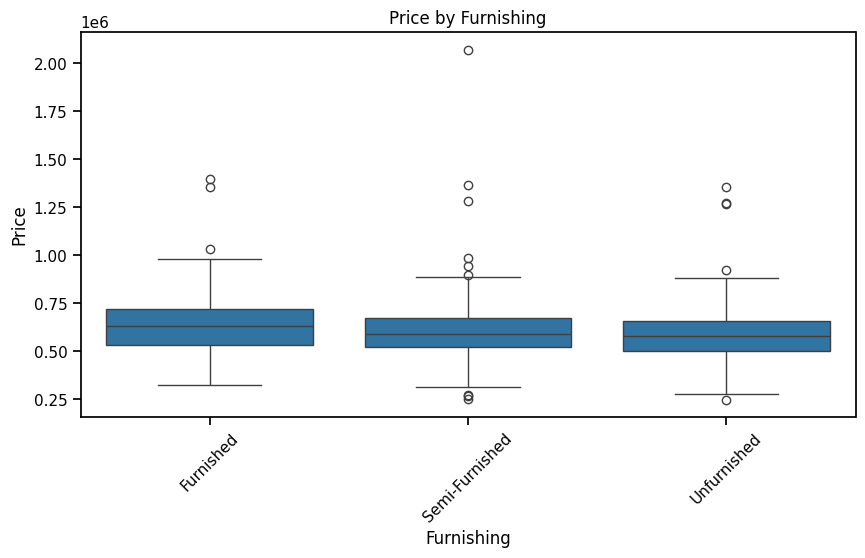

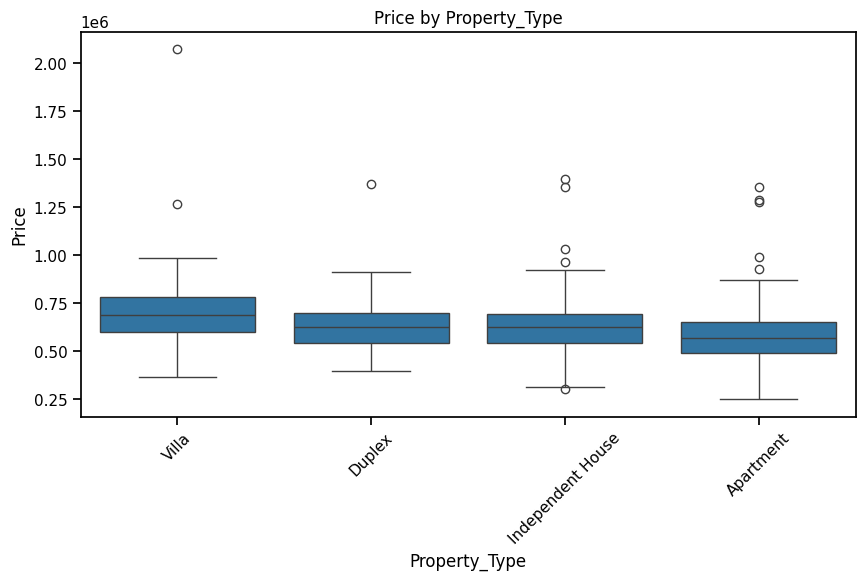

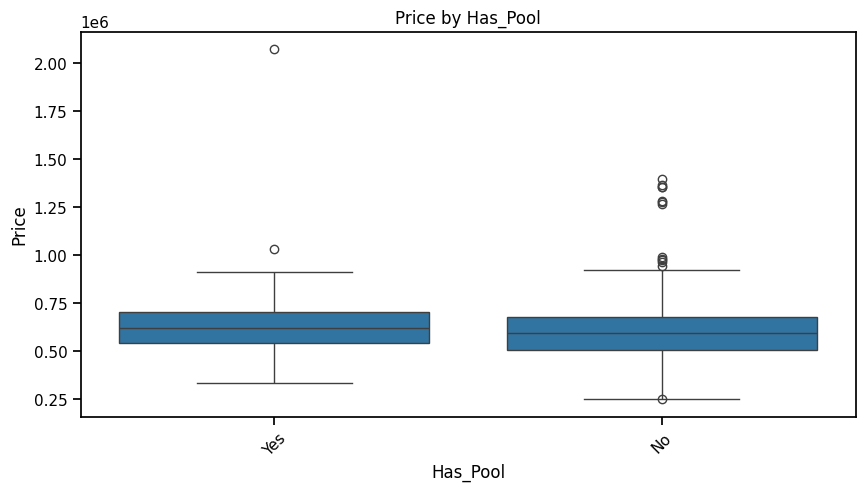

In [24]:
for col in categorical_cols:
    plt.figure(figsize=(10, 5))
    order = df.groupby(col)["Price"].median().sort_values(ascending=False).index
    sns.boxplot(data=df, x=col, y="Price", order=order)
    plt.title(f"Price by {col}")
    plt.xticks(rotation=45)
    plt.show()

## 10. Correlation Analysis

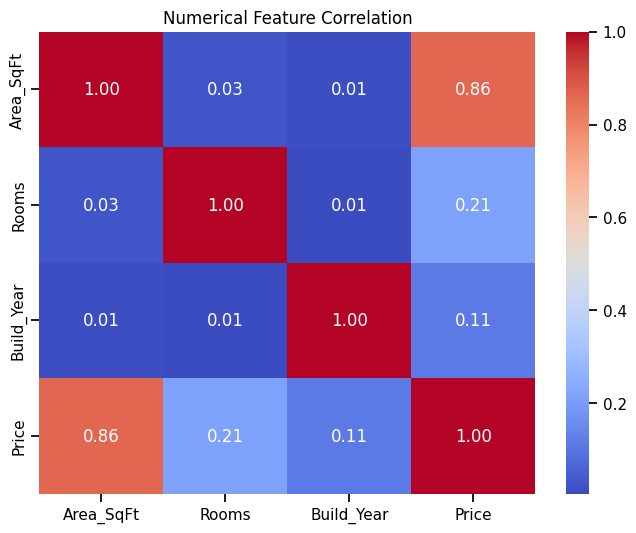

In [25]:
plt.figure(figsize=(8, 6))
sns.heatmap(df[numeric_cols].corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Numerical Feature Correlation")
plt.show()

## 11. Feature Engineering

We create useful features:

- `House_Age`: Current year minus build year
- `Price_Per_SqFt`: Used for EDA only, not for model training because it uses target `Price`
- `Area_Room_Ratio`: Area divided by number of rooms

In [26]:
df_fe = df.copy()

CURRENT_YEAR = 2026
df_fe["House_Age"] = CURRENT_YEAR - df_fe["Build_Year"]
df_fe["Area_Room_Ratio"] = df_fe["Area_SqFt"] / df_fe["Rooms"]

# EDA-only feature because it uses target column
df_fe["Price_Per_SqFt"] = df_fe["Price"] / df_fe["Area_SqFt"]

df_fe.head()

,Area_SqFt,Rooms,Build_Year,Location,Street_Type,Furnishing,Property_Type,Has_Pool,Price,House_Age,Area_Room_Ratio,Price_Per_SqFt
0,2473.192784,4.0,1992,Jaipur,Residential Lane,Furnished,Apartment,No,568486.0,34,618.298196,229.859154
1,2353.472711,4.0,2006,Indore,Corner Plot,Unfurnished,Apartment,Yes,577214.0,20,588.368178,245.260545
2,2212.222005,3.0,2012,Jaipur,Highway Facing,Semi-Furnished,Duplex,No,581300.0,14,737.407335,262.767479
3,2823.886596,6.0,1993,Lucknow,Main Road,Unfurnished,Villa,Yes,794614.0,33,470.647766,281.390195
4,1869.648721,5.0,2012,Jaipur,Corner Plot,Semi-Furnished,Apartment,No,493086.0,14,373.929744,263.731895


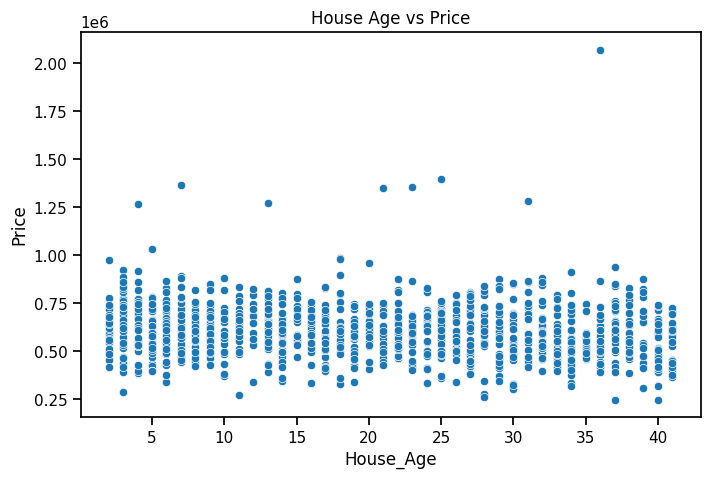

In [27]:
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df_fe, x="House_Age", y="Price")
plt.title("House Age vs Price")
plt.show()

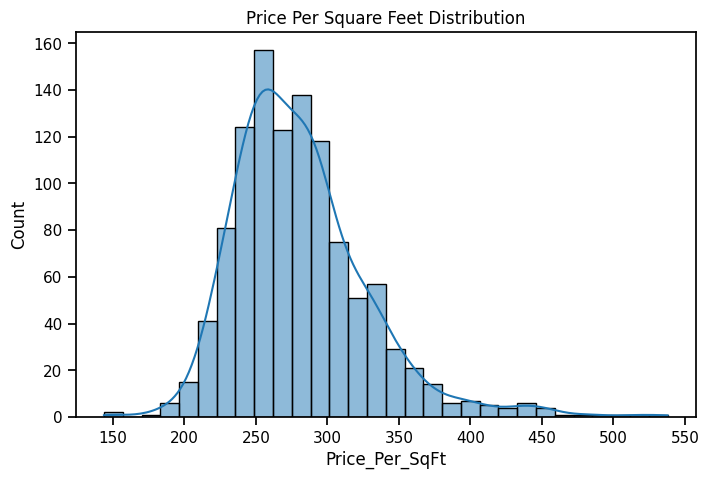

In [28]:
plt.figure(figsize=(8, 5))
sns.histplot(df_fe["Price_Per_SqFt"], kde=True, bins=30)
plt.title("Price Per Square Feet Distribution")
plt.show()

## 12. Prepare Data for Modeling

Important: `Price_Per_SqFt` is removed because it directly uses the target variable and would cause data leakage.

In [29]:
model_df = df_fe.drop(columns=["Price_Per_SqFt"])

X = model_df.drop(columns=["Price"])
y = model_df["Price"]

num_features = X.select_dtypes(include=[np.number]).columns.tolist()
cat_features = X.select_dtypes(include="object").columns.tolist()

print("Numerical Features:", num_features)
print("Categorical Features:", cat_features)

Numerical Features: ['Area_SqFt', 'Rooms', 'Build_Year', 'House_Age', 'Area_Room_Ratio']
Categorical Features: ['Location', 'Street_Type', 'Furnishing', 'Property_Type', 'Has_Pool']


## 13. Train-Test Split

In [30]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (899, 10)
X_test: (225, 10)
y_train: (899,)
y_test: (225,)


## 14. Preprocessing Pipeline

- Numerical columns: median imputation + scaling
- Categorical columns: most frequent imputation + one-hot encoding

In [31]:
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(transformers=[
    ("num", numeric_transformer, num_features),
    ("cat", categorical_transformer, cat_features)
])

## 15. Model Training and Evaluation Function

In [32]:
def evaluate_model(name, model, X_train, X_test, y_train, y_test):
    pipeline = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("model", model)
    ])

    pipeline.fit(X_train, y_train)
    preds = pipeline.predict(X_test)

    mae = mean_absolute_error(y_test, preds)
    rmse = np.sqrt(mean_squared_error(y_test, preds))
    r2 = r2_score(y_test, preds)
    mape = np.mean(np.abs((y_test - preds) / y_test)) * 100

    result = {
        "Model": name,
        "MAE": mae,
        "RMSE": rmse,
        "R2_Score": r2,
        "MAPE": mape
    }

    return pipeline, result

## 16. Train Multiple Models

In [44]:
models = {
    "Linear Regression": LinearRegression(),
    "Ridge Regression": Ridge(alpha=1.0),
    "Lasso Regression": Lasso(alpha=0.1),
    "Random Forest": RandomForestRegressor(n_estimators=300, random_state=42),
    "Gradient Boosting": GradientBoostingRegressor(random_state=42)
}

trained_pipelines = {}
results = []

for name, model in models.items():
    pipeline, result = evaluate_model(name, model, X_train, X_test, y_train, y_test)
    trained_pipelines[name] = pipeline
    results.append(result)

results_df = pd.DataFrame(results).sort_values(by="R2_Score", ascending=False)
results_df

,Model,MAE,RMSE,R2_Score,MAPE
4,Gradient Boosting,25323.924916,33077.707087,0.948226,4.284460
1,Ridge Regression,20314.020393,34159.993909,0.944783,3.316489
0,Linear Regression,20263.509906,34175.393200,0.944733,3.308089
2,Lasso Regression,20263.536905,34175.492428,0.944732,3.308093
3,Random Forest,35140.690002,44538.203273,0.906134,5.999618


## 17. Model Comparison Visualization

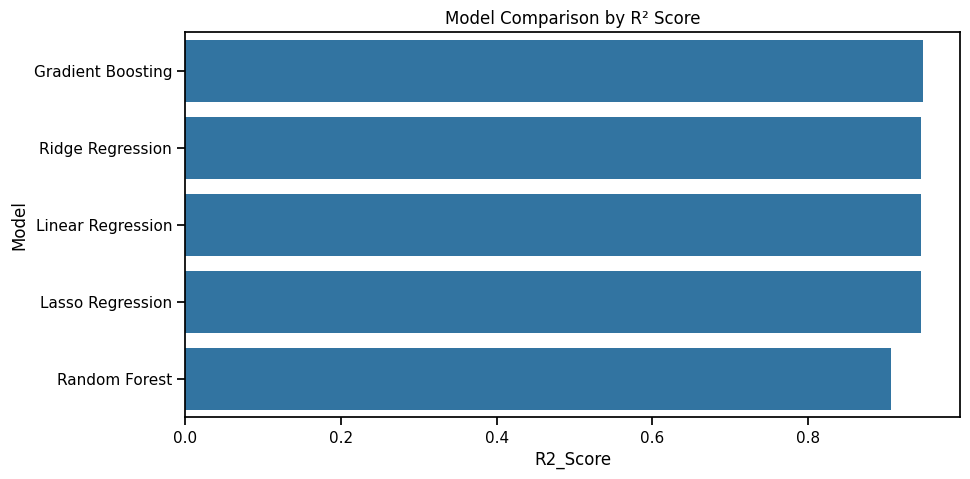

In [34]:
plt.figure(figsize=(10, 5))
sns.barplot(data=results_df, x="R2_Score", y="Model")
plt.title("Model Comparison by R² Score")
plt.show()

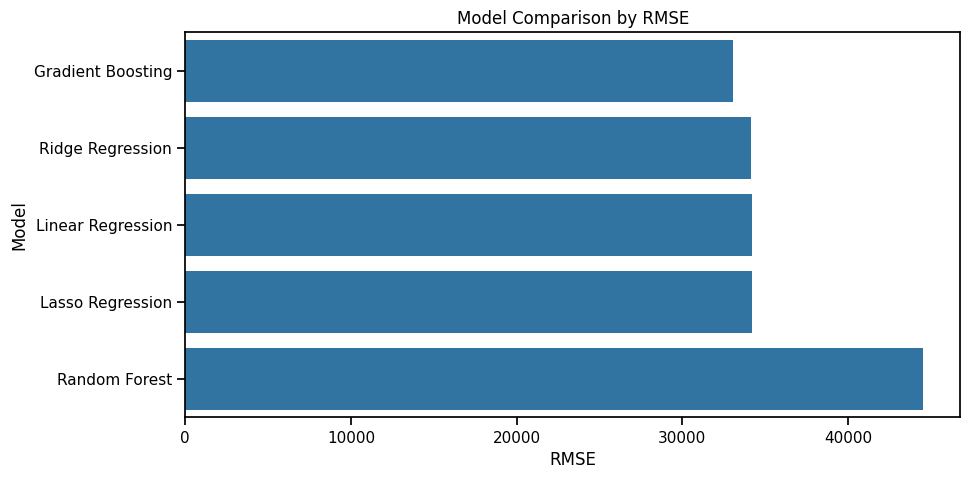

In [35]:
plt.figure(figsize=(10, 5))
sns.barplot(data=results_df.sort_values("RMSE"), x="RMSE", y="Model")
plt.title("Model Comparison by RMSE")
plt.show()

## 18. Best Model Selection

In [36]:
best_model_name = results_df.iloc[0]["Model"]
best_pipeline = trained_pipelines[best_model_name]

print("Best Model:", best_model_name)
print(results_df.iloc[0])

Best Model: Gradient Boosting
Model       Gradient Boosting
MAE              25323.924916
RMSE             33077.707087
R2_Score             0.948226
MAPE                  4.28446
Name: 4, dtype: object


## 19. Actual vs Predicted Plot

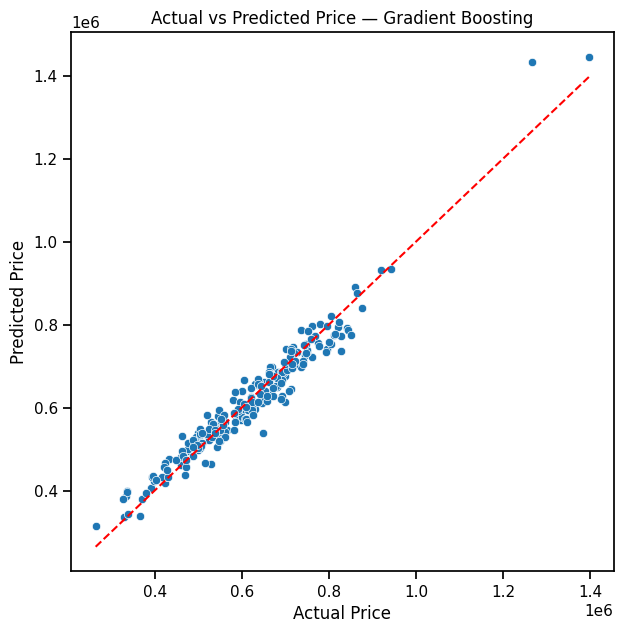

In [37]:
y_pred = best_pipeline.predict(X_test)

plt.figure(figsize=(7, 7))
sns.scatterplot(x=y_test, y=y_pred)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title(f"Actual vs Predicted Price — {best_model_name}")
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], "r--")
plt.show()

## 20. Residual Analysis

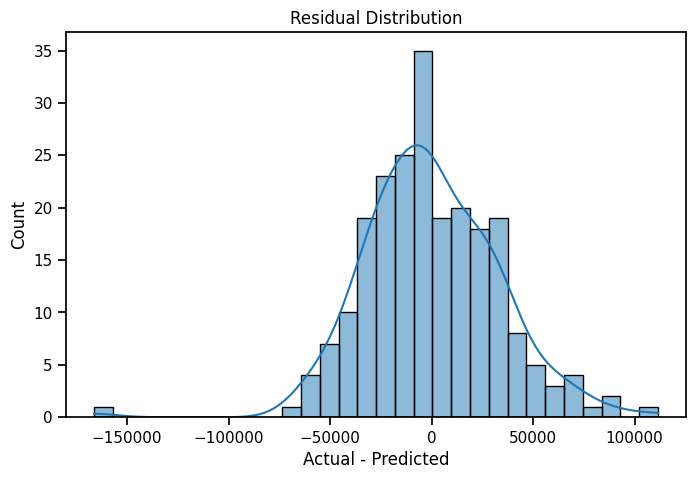

In [38]:
residuals = y_test - y_pred

plt.figure(figsize=(8, 5))
sns.histplot(residuals, kde=True, bins=30)
plt.title("Residual Distribution")
plt.xlabel("Actual - Predicted")
plt.show()

## 21. Feature Importance

For tree-based models, we can inspect feature importance after preprocessing.

,Feature,Importance
0,Area_SqFt,0.758006
21,Property_Type_Apartment,0.052487
1,Rooms,0.035640
24,Property_Type_Villa,0.023777
5,Location_Delhi,0.017610
25,Has_Pool_No,0.013621
6,Location_Gurugram,0.012050
18,Furnishing_Furnished,0.010763
2,Build_Year,0.010131
11,Location_Noida,0.008990


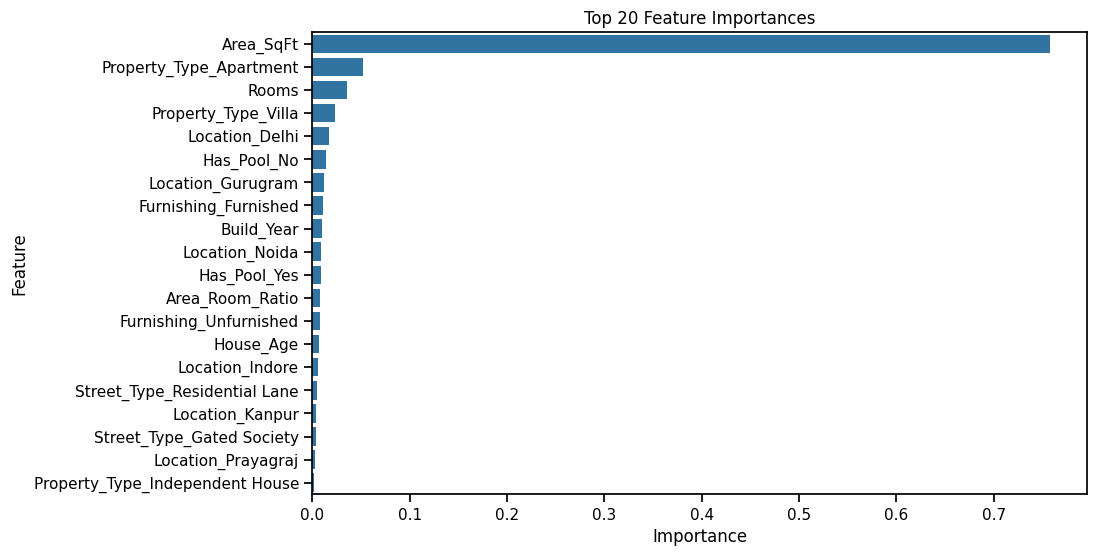

In [39]:
try:
    model_step = best_pipeline.named_steps["model"]

    if hasattr(model_step, "feature_importances_"):
        ohe = best_pipeline.named_steps["preprocessor"].named_transformers_["cat"].named_steps["onehot"]
        cat_names = ohe.get_feature_names_out(cat_features)
        all_feature_names = num_features + list(cat_names)

        importance_df = pd.DataFrame({
            "Feature": all_feature_names,
            "Importance": model_step.feature_importances_
        }).sort_values(by="Importance", ascending=False).head(20)

        display(importance_df)

        plt.figure(figsize=(10, 6))
        sns.barplot(data=importance_df, x="Importance", y="Feature")
        plt.title("Top 20 Feature Importances")
        plt.show()
    else:
        print("Best model does not provide feature_importances_.")
except Exception as e:
    print("Feature importance could not be displayed:", e)

## 22. Prediction Example

In [40]:
sample = X_test.iloc[[0]].copy()
actual_price = y_test.iloc[0]
predicted_price = best_pipeline.predict(sample)[0]

print("Sample Input:")
display(sample)
print("Actual Price:", actual_price)
print("Predicted Price:", round(predicted_price, 2))

Sample Input:


,Area_SqFt,Rooms,Build_Year,Location,Street_Type,Furnishing,Property_Type,Has_Pool,House_Age,Area_Room_Ratio
1088,3164.257141,7.0,2001,Lucknow,Residential Lane,Unfurnished,Apartment,No,25,452.036734


Actual Price: 700394.0
Predicted Price: 741938.34


## 23. Save Best Model

This saved pipeline includes both preprocessing and the trained model.

In [41]:
model_filename = "house_price_prediction_pipeline.pkl"
joblib.dump(best_pipeline, model_filename)
print("Model saved as:", model_filename)

Model saved as: house_price_prediction_pipeline.pkl


## 24. Load Saved Model and Test Prediction

In [42]:
loaded_model = joblib.load(model_filename)
loaded_prediction = loaded_model.predict(sample)[0]
print("Loaded Model Prediction:", round(loaded_prediction, 2))

Loaded Model Prediction: 741938.34


## 25. Conclusion

In this notebook, we completed an end-to-end machine learning workflow for house price prediction.

### Completed Steps

- Dataset loading and understanding
- Missing value analysis
- EDA for numerical and categorical features
- Feature engineering
- Preprocessing pipeline
- Multiple regression model training
- Model comparison using MAE, RMSE, R², and MAPE
- Best model selection
- Model saving for deployment

### Next Step

Use the saved file `house_price_prediction_pipeline.pkl` inside a **Streamlit app** or **FastAPI API** to build a real house price prediction web application.